In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phd_project.config.config import load_config 
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    preliminary_record_selection
)

from phd_project.scripts.WP1_ground_motion_set.setup_AvgSA06_gm_selection import (
    setup_AvgSA06_gcim_gm_selection,
    setup_AvgSA06_gcim_gm_selection_w_IA
    )

from phd_project.plotting.plotting import (
    plot_im_ecdf_vs_target,
    apply_grid_lines
)

cfg = load_config()

C:\Users\clemettn\Documents\phd\phd_project\scripts\WP1_ground_motion_set\gm_selection.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# Comaprison of Selection Cases - AvgSA([0, 6])

In [3]:
# file paths:
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_06.pickle"

# other stuff:
rng_seed = 1


In [4]:
# load the gcim distributions
if gcim_dist_fp.is_file():
    with open(gcim_dist_fp, "rb") as file:
        gcim_dists = pickle.load(file)
    print("Existing GCIM distribution data loaded...")
else:
    print("No existing GCIM distribution data found...")

Existing GCIM distribution data loaded...


In [5]:
site = 30
poe = 0.000404

## Case 1: RSD595 = 0.25, IA not included

In [6]:
only_select = [(site, poe)]

# set up the record selection
site_poe_disaggs, disagg_stats, site_model, basic_selection_ctx, gm_db = setup_AvgSA06_gcim_gm_selection(weight_rsd595=0.25)

prelim_ensembles, prelim_ensembles_not_passing, no_preliminary_ensembles, candidate_ensembles = preliminary_record_selection(
    site_poe_disaggs, disagg_stats, gcim_dists, gm_db, basic_selection_ctx, site_model, rng_seed, 
    preliminary_selection_fp=None, only_select=only_select, load_rs_if_exists=False)
e1a = prelim_ensembles[(site, poe)]
c1a = candidate_ensembles[(site, poe)]

Selecting GM Ensembles:   0%|          | 0/1 [00:00<?, ?it/s]

Sub-Optimal! - Preliminary ensembles do not pass for 1 combinations of site and poe


## Case 1b: RSD595 = 0.25, IA = 0.0

Case 1b should give the same results as Case 1 --> but it won't because of the random number generator.
By adding IA into the mix we change the simulated distributions for a given sequence of random numbers.

In [7]:
only_select = [(site, poe)]

# set up the record selection
site_poe_disaggs, disagg_stats, site_model, basic_selection_ctx, gm_db = setup_AvgSA06_gcim_gm_selection_w_IA(weight_rsd595=0.25, weight_ia=0.0)

prelim_ensembles, prelim_ensembles_not_passing, no_preliminary_ensembles, candidate_ensembles = preliminary_record_selection(
    site_poe_disaggs, disagg_stats, gcim_dists, gm_db, basic_selection_ctx, site_model, rng_seed, 
    preliminary_selection_fp=None, only_select=only_select, load_rs_if_exists=False)
e1b = prelim_ensembles[(site, poe)]
c1b = candidate_ensembles[(site, poe)]

Selecting GM Ensembles:   0%|          | 0/1 [00:00<?, ?it/s]

Sub-Optimal! - Preliminary ensembles do not pass for 1 combinations of site and poe


## Case 2: RSD595 = 0.125, IA = 0.125 

In [8]:
only_select = [(site, poe)]

# set up the record selection
site_poe_disaggs, disagg_stats, site_model, basic_selection_ctx, gm_db = setup_AvgSA06_gcim_gm_selection_w_IA(weight_rsd595=0.1, weight_ia=0.3)

# allow all records to be considered
basic_selection_ctx["m_bound_model"] = None
basic_selection_ctx["d_bound_model"] = None
basic_selection_ctx["vs30_bound_model"] = None

prelim_ensembles, prelim_ensembles_not_passing, no_preliminary_ensembles, candidate_ensembles = preliminary_record_selection(
    site_poe_disaggs, disagg_stats, gcim_dists, gm_db, basic_selection_ctx, site_model, rng_seed, 
    preliminary_selection_fp=None, only_select=only_select, load_rs_if_exists=False)
e2 = prelim_ensembles[(site, poe)]
c2 = candidate_ensembles[(site, poe)]

Selecting GM Ensembles:   0%|          | 0/1 [00:00<?, ?it/s]

Sub-Optimal! - Preliminary ensembles do not pass for 1 combinations of site and poe


Text(0.5, 0, 'SA(2.525) [g]')

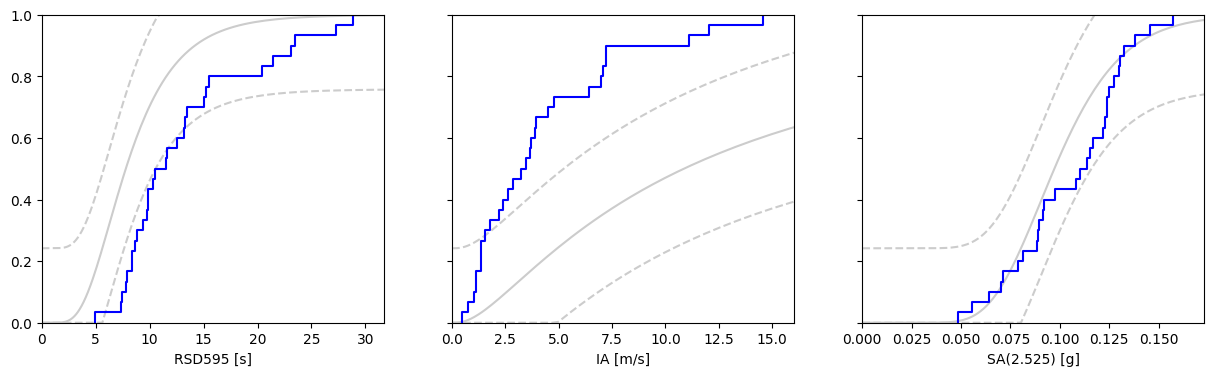

In [9]:
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
plot_im_ecdf_vs_target(ax1, e2["ecdfs"]["RSD595"], e2["ks_bounds"]["RSD595"])
ax1.set_xlabel("RSD595 [s]")
ia_ecdf = e2["ecdfs"]["IA"].copy()
# ia_ecdf[:,0] *= 5.2
plot_im_ecdf_vs_target(ax2, ia_ecdf, e2["ks_bounds"]["IA"])
ax2.set_xlabel("IA [m/s]")
plot_im_ecdf_vs_target(ax3, e2["ecdfs"]["SA(2.525)"], e2["ks_bounds"]["SA(2.525)"])
ax3.set_xlabel("SA(2.525) [g]")

The target distribution for Arias Intensity does not appear to be a very good fit for our database as even when all possible records are available and IA is weighted highly we are unable to get a good match for the distribution. This warrants some further investigation...

To investigate this issue I will compare teh Bahrampouri ASC GMM against Sadikkaya and Akkar (2017) which is implemented in Openquake and Huang et al. (2020)

In [10]:
from openquake.hazardlib.gsim import registry
from openquake.hazardlib.imt import IA

# GMM Checks

## Checking B21 GMM against data from corresponding Paper

In [11]:
def create_ctx(ctx_dict):
    # 1. Prepare rows and field names
    rows = list(zip(*ctx_dict.values()))
    names = list(ctx_dict.keys())

    # 2. Create the recarray using the non-deprecated rec module
    ctx_arr = np.rec.fromrecords(rows, names=names)
    return ctx_arr

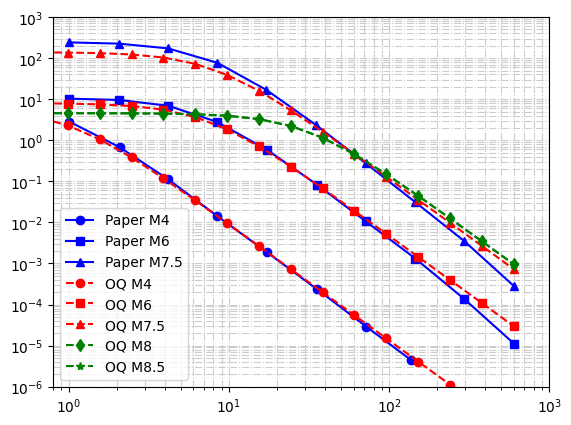

In [12]:
# calculating the openquake gmm values from the parameters in the paper Figure 9a
b21_asc = registry["BahrampouriEtAl2021Asc"]()
imts = [IA()]


def calculate_fig9a_values(mag, gmm):
    distances = np.geomspace(0.1, 600, num=20)
    n = len(distances)

    ctx_dict = {
    "mag": [mag]*n,
    "rrup": distances,
    "ztor": [10.0]*n,
    "hypo_lat": [0.0]*n,
    "hypo_lon": [0.0]*n,
    "lat": [0.0]*n,
    "lon": [0.0]*n,
    "vs30": [750]*n,
    }

    ctx_arr = create_ctx(ctx_dict)

    mean = np.zeros((len(imts), n))
    sigma = np.zeros_like(mean)
    tau = np.zeros_like(mean)
    phi = np.zeros_like(mean)

    gmm.compute(ctx_arr, imts, mean, sigma, tau, phi)
    return distances, mean[0,:], sigma[0,:], tau[0,:], phi[0,:]

distances, b21_mean_m4, *_ = calculate_fig9a_values(mag=4, gmm=b21_asc)
_, b21_mean_m6, *_ = calculate_fig9a_values(mag=6, gmm=b21_asc)
_, b21_mean_m7pt5, *_ = calculate_fig9a_values(mag=7.5, gmm=b21_asc)
_, b21_mean_m8, *_ = calculate_fig9a_values(mag=8, gmm=b21_asc)
_, b21_mean_m8pt5, *_ = calculate_fig9a_values(mag=8.5, gmm=b21_asc)

# Comparing the values from the Baharampouri et al. (2021) paper with the 
# values calculated using the GSIM equations in OpenQuake. 
b21_paper_m4_asc = np.loadtxt(r"C:\Users\clemettn\Documents\phd\data_raw\digistised_ai_gmm_data\B21_ASC_M4.csv", delimiter=",", encoding="UTF-8")
b21_paper_m6_asc = np.loadtxt(r"C:\Users\clemettn\Documents\phd\data_raw\digistised_ai_gmm_data\B21_ASC_M6.csv", delimiter=",", encoding="UTF-8")
b21_paper_m7pt5_asc = np.loadtxt(r"C:\Users\clemettn\Documents\phd\data_raw\digistised_ai_gmm_data\B21_ASC_M7pt5.csv", delimiter=",", encoding="UTF-8")

fig, ax = plt.subplots()
ax.loglog(b21_paper_m4_asc[:,0], b21_paper_m4_asc[:,1], label="Paper M4", color="b", marker="o")
ax.loglog(b21_paper_m6_asc[:,0], b21_paper_m6_asc[:,1], label="Paper M6", color="b", marker="s")
ax.loglog(b21_paper_m7pt5_asc[:,0], b21_paper_m7pt5_asc[:,1], label="Paper M7.5", color="b", marker="^")

ax.loglog(distances, np.exp(b21_mean_m4), label="OQ M4", color="r", marker="o", ls="--")
ax.loglog(distances, np.exp(b21_mean_m6), label="OQ M6", color="r", marker="s", ls="--")
ax.loglog(distances, np.exp(b21_mean_m7pt5), label="OQ M7.5", color="r", marker="^", ls="--")
ax.loglog(distances, np.exp(b21_mean_m8), label="OQ M8", color="g", marker="d", ls="--")
ax.loglog(distances, np.exp(b21_mean_m8), label="OQ M8.5", color="g", marker="*", ls="--")

apply_grid_lines(ax)

ax.set_ylim(1e-6, 1e3)
ax.set_xlim(0.8, 1000)
ax.legend()

The values from the OQ implementation of the GMM more or less match the data from the paper up to Mw = 7.5. Mw 8 and above have some sort of error and they just return the same values. This is a problem for my study because we have ground motions with > M8 contributing to the hazard. This model does not appear to support extrapolation of M, despite the fact that Figure 10 implies that this should be possible.

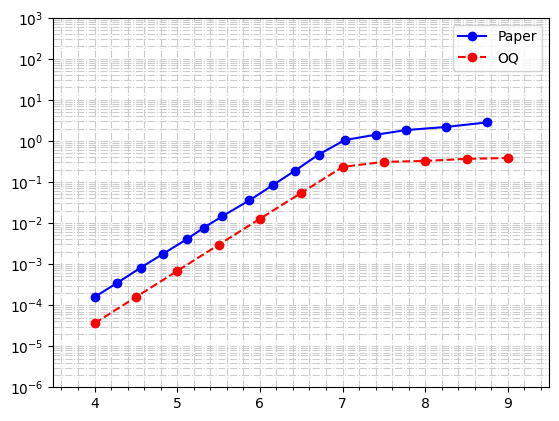

In [13]:
# plot figure 10
def calculate_fig10_values(gmm):
    mags = [4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9]
    n = len(mags)

    ctx_dict = {
    "mag": mags,
    "rrup": [70.0]*n,
    "ztor": [10.0]*n,
    "hypo_lat": [0.0]*n,
    "hypo_lon": [0.0]*n,
    "lat": [0.0]*n,
    "lon": [0.0]*n,
    "vs30": [760]*n,
    }

    ctx_arr = create_ctx(ctx_dict)

    mean = np.zeros((len(imts), n))
    sigma = np.zeros_like(mean)
    tau = np.zeros_like(mean)
    phi = np.zeros_like(mean)

    gmm.compute(ctx_arr, imts, mean, sigma, tau, phi)
    return mags, mean[0,:], sigma[0,:], tau[0,:], phi[0,:]

mags, b21_asc_mean_mags, *_ = calculate_fig10_values(gmm=registry["BahrampouriEtAl2021Asc"]())
b21_paper_asc_mags = np.loadtxt(r"C:\Users\clemettn\Documents\phd\data_raw\digistised_ai_gmm_data\B21_asc_r70_vs30-760.csv", delimiter=",", encoding="UTF-8")

fig, ax = plt.subplots()
ax.semilogy(b21_paper_asc_mags[:,0], b21_paper_asc_mags[:,1], label="Paper", color="b", marker="o", ls="-")
ax.semilogy(mags, np.exp(b21_asc_mean_mags), label="OQ", color="r", marker="o", ls="--")


apply_grid_lines(ax)
ax.set_ylim(1e-6, 1e3)
ax.set_xlim(3.5, 9.5)
ax.legend()

The data in the above plot do not match at all. In this case the data in paper is higher than what is produced by Openquake. No value for Ztor is given in the paper, but I have used 10 km which they commonly use. To get values of the same order of magnitude Ztor needs to be increase to 60-70 km , which is too deep for a shallow crustal earthquake. Dummy values of lat, lon, hypo_lat and hypo_lon have been used so that the Ck and Cm values are 0.

## Comparing the B21 GMM with other European IA GMMs for active shallow crust

Text(0, 0.5, 'Ratio B21 / S17')

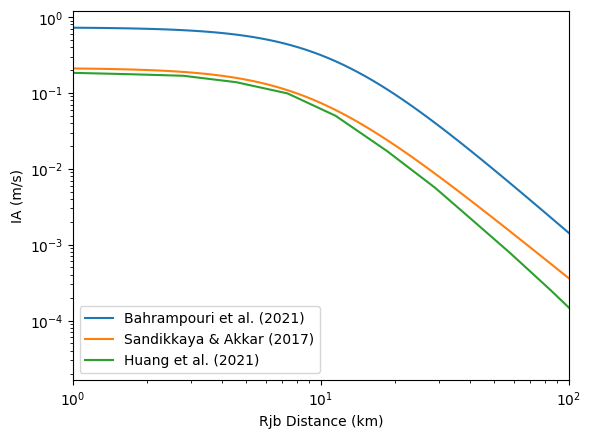

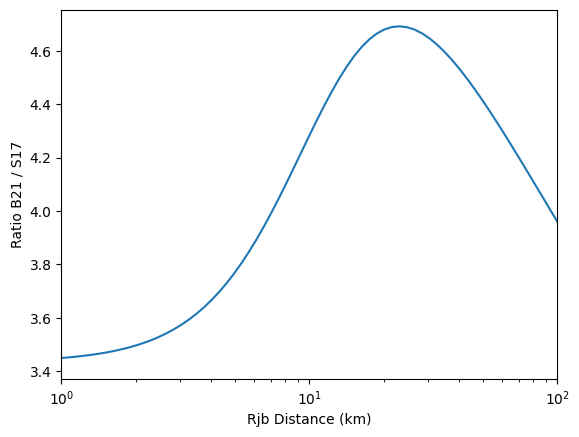

In [15]:

# Figure 3d from Huang et al. (2020). Extracted data is used for the HTG20 GMM,
# but the OQ implementation is used for SA17 and B21 for comparison.

def calculate_fig3a_values(mag, gmm):
    distances = np.geomspace(0.1, 100, num=100)
    n = len(distances)

    ctx_dict = {
    "mag": [mag]*n,
    "rrup": np.sqrt(distances**2 + 10 ** 2),
    "rjb": distances,
    "repi": distances,
    "ztor": [10.0]*n,           # basically our default value for ztor
    "hypo_lat": [0.0]*n,
    "hypo_lon": [0.0]*n,
    "lat": [0.0]*n,
    "lon": [0.0]*n,
    "vs30": [580]*n,
    "rake": [-90.0]*n
    }

    ctx_arr = create_ctx(ctx_dict)

    mean = np.zeros((len(imts), n))
    sigma = np.zeros_like(mean)
    tau = np.zeros_like(mean)
    phi = np.zeros_like(mean)

    gmm.compute(ctx_arr, imts, mean, sigma, tau, phi)
    return mean[0,:], ctx_dict["rrup"], ctx_dict["rjb"]

b21 = registry["BahrampouriEtAl2021Asc"]()
imts = [IA()]

mag = 5.5
b21_mean, rrup, _ = calculate_fig3a_values(mag=mag, gmm=registry["BahrampouriEtAl2021Asc"]())
s17_mean, _, rjb = calculate_fig3a_values(mag=mag, gmm=registry["SandikkayaAkkar2017Repi"]())

huang =pd.read_csv(r"C:\Users\clemettn\Documents\phd\data_raw\haung_et_al_IA_gmm\mw_5pt5_vs30_580.txt", delimiter=",", encoding="UTF-8", header=None).to_numpy()

fig, ax = plt.subplots()
ax.loglog(rjb, np.exp(b21_mean), label="Bahrampouri et al. (2021)")     # plotting against rjb for consistency with the Huang et al. (2020) figure, even though the B21 GMM is defined in terms of rrup
ax.loglog(rjb, np.exp(s17_mean), label="Sandikkaya & Akkar (2017)")
ax.loglog(huang[:,0], huang[:,1] / 100, label="Huang et al. (2021)")    # convert from cm/s to m/s
ax.set_xlim(1, 100)
ax.set_xlabel("Rjb Distance (km)")
ax.set_ylabel("IA (m/s)")
ax.legend()

fig, ax = plt.subplots()
ax.semilogx(rjb, np.exp(b21_mean) / np.exp(s17_mean))
ax.set_xlim(1, 100)
ax.set_xlabel("Rjb Distance (km)")
ax.set_ylabel("Ratio B21 / S17")

From the first plot it is clear that the HTG20 and S17 are close to each other. The B21 mean values are substantially higher. For this case the values are approximately 4x larger as evidences in the bottom plot. Interestingly if we set mag = 6.3 this ratio is approximatel 5.2. If the target IA distribution of Case 2 is downscaled by this factor (or the ecdf is upscaled) the target and actual distribution fit really nicely together...
This is obviously an approximation, but the site is dominated by shallow crustal earthquakes at a distance of 5 km. So it is not too big of an leap to make this comparison.

This leads me to believe that this GMM is not a great fit for our database even though Sotiriadis (2022) suggests that it should be quite a good fit. I think a better option would be Huang et al (which is not implemented) or Sadikayya Akkar 2017 (which is only defined for active shallow crust regions.) A new GMM would need to be found for the subduction cases.

I do not have the time to investigate this. We will not consider IA in our record selection.